# Missing Data Patterns and Simulation Scenarios

This notebook continues exploring missing data by asking what happens when missing values are not spread evenly across the dataset.

This lesson focuses on the shape of the missingness before a strategy is chosen. Missing data can be concentrated in one species, one plot, one year, or one event. When that happens, the analysis can change even if the total amount of missing data looks manageable.

The goal is to compare four studies:

- Which species, plots, or years already have high measurement missingness?
- What happens if 20% of measurement values are randomly trashed across the whole dataset?
- What happens if the whole dataset has random missingness, but one species also loses extra data?
- What happens if a plot-level event, such as a flood, removes usable measurements from one plot-year?


---
## Load the data

The original table is used because it still contains the missing measurement values that the simplified dataset has already filtered out.


In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RANDOM_SEED = 42

raw_df = (
    pd.read_csv('../../data/Portal_rodent.csv', low_memory=False)
    .rename(columns={
        'recordID': 'record_id',
        'plot': 'plot_id',
        'species': 'species_id',
        'hfl': 'hindfoot_length',
        'wgt': 'weight'
    })
)

plots_df = pd.read_csv('../../data/plots.csv')
species_df = pd.read_csv('../../data/species.csv')

raw_df['species_id'] = raw_df['species_id'].astype('string').str.strip()
raw_df['sex'] = raw_df['sex'].astype('string').str.strip()
raw_df['weight'] = pd.to_numeric(raw_df['weight'], errors='coerce')
raw_df['hindfoot_length'] = pd.to_numeric(raw_df['hindfoot_length'], errors='coerce')
raw_df['plot_id'] = pd.to_numeric(raw_df['plot_id'], errors='coerce')
raw_df['year'] = pd.to_numeric(raw_df['year'], errors='coerce')

lesson_df = raw_df.merge(plots_df, on='plot_id', how='left')
lesson_df = lesson_df.merge(species_df, on='species_id', how='left')
lesson_df[['record_id', 'year', 'month', 'plot_id', 'plot_type', 'species_id', 'sex', 'hindfoot_length', 'weight']].head()


,record_id,year,month,plot_id,plot_type,species_id,sex,hindfoot_length,weight
0,1,1977,7,2.0,Control,<NA>,M,32.0,NaN
1,2,1977,7,3.0,Long-term Krat Exclosure,<NA>,M,33.0,NaN
2,3,1977,7,2.0,Control,DM,F,37.0,NaN
3,4,1977,7,7.0,Rodent Exclosure,DM,M,36.0,NaN
4,5,1977,7,3.0,Long-term Krat Exclosure,DM,M,35.0,NaN


## Prepare the lesson dataset

This cell keeps the records that have a species, plot, and year. It also creates a single indicator called measurement_missing, which is True when either weight or hindfoot_length is missing.

The simulation sections use rows with observed positive weight as the baseline. That gives us a known starting point before we intentionally create missing data.


In [76]:
measurement_cols = ['weight', 'hindfoot_length']

analysis_df = lesson_df.dropna(subset=['species_id', 'year', 'plot_id']).copy()
analysis_df['measurement_missing'] = analysis_df[measurement_cols].isna().any(axis=1)

complete_weight_df = (
    analysis_df
    .dropna(subset=['weight'])
    .loc[lambda data: data['weight'] > 0]
    .copy()
)

print(f'Rows with species, plot, and year: {len(analysis_df):,}')
print(f'Rows with observed positive weight: {len(complete_weight_df):,}')
print(f'Percent with missing weight or hindfoot length: {analysis_df["measurement_missing"].mean() * 100:.1f}%')


Rows with species, plot, and year: 75,923
Rows with observed positive weight: 72,472
Percent with missing weight or hindfoot length: 6.5%


## Study 1: Find where missingness is concentrated

**Scenario/question:** Before dropping or imputing anything, which groups are already missing a lot of measurement data?


In [77]:
def summarize_missingness(data, group_col, min_rows=100):
    summary = (
        data.groupby(group_col, dropna=False)
        .agg(
            n_records=('record_id', 'size'),
            missing_percent=('measurement_missing', lambda values: values.mean() * 100)
        )
        .reset_index()
    )
    return summary.loc[summary['n_records'] >= min_rows].sort_values('missing_percent', ascending=False)

species_missing = summarize_missingness(analysis_df, 'species_id', min_rows=100).head(10)
plot_missing = summarize_missingness(analysis_df, 'plot_id', min_rows=100).head(10)
yearly_missing = (
    analysis_df.groupby('year')
    .agg(n_records=('record_id', 'size'), missing_percent=('measurement_missing', lambda values: values.mean() * 100))
    .reset_index()
    .sort_values('year')
)

print('Top 10 species with highest missingness:')
display(species_missing)

print('Top 10 plots with highest missingness:')
display(plot_missing)

print('Yearly missingness:')
display(yearly_missing)

Top 10 species with highest missingness:


,species_id,n_records,missing_percent
0,AB,341,100.000000
1,AH,539,100.000000
39,SS,353,100.000000
11,DS,2575,18.601942
37,SH,520,7.884615
14,OL,1444,7.756233
20,PF,2124,6.167608
25,PM,1191,5.793451
30,RM,3750,5.573333
10,DO,5758,5.140674


Top 10 plots with highest missingness:


,plot_id,n_records,missing_percent
9,10.0,591,11.844332
22,23.0,1312,11.356707
15,16.0,1304,10.122699
14,15.0,2520,10.000000
19,20.0,3130,8.849840
12,13.0,3303,8.477142
23,24.0,2137,7.627515
6,7.0,2354,7.051827
11,12.0,3983,6.929450
8,9.0,3497,6.920217


Yearly missingness:


,year,n_records,missing_percent
0,1977,456,43.859649
1,1978,944,17.161017
2,1979,628,10.350318
3,1980,1318,31.335357
4,1981,1354,27.843427
5,1982,1853,20.831085
6,1983,1554,6.435006
7,1984,886,8.465011
8,1985,1371,6.710430
9,1986,862,8.932715


The analysis above creates three summary tables: missingness by species, missingness by plot, and missingness by year. If the missingness rate was the same everywhere, these summaries would look fairly flat. If some groups are much higher than others, missingness has structure.

This matters because dropping rows is less risky when missingness is small and evenly spread. If missingness is concentrated in a particular species, plot, or year, dropping rows can quietly change the comparison before the main analysis even starts.


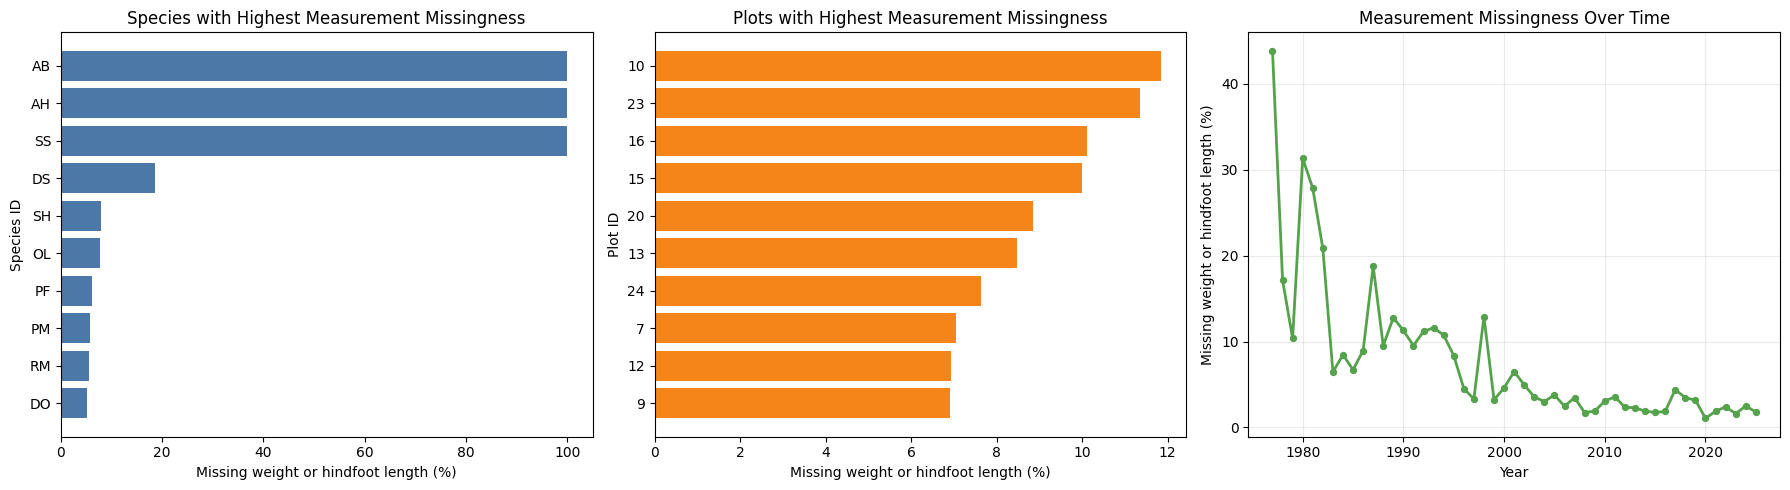

In [78]:
# FIG 9.1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(species_missing['species_id'].astype(str), species_missing['missing_percent'], color='#4C78A8')
axes[0].invert_yaxis()
axes[0].set_title('Species with Highest Measurement Missingness')
axes[0].set_xlabel('Missing weight or hindfoot length (%)')
axes[0].set_ylabel('Species ID')

axes[1].barh(plot_missing['plot_id'].astype(int).astype(str), plot_missing['missing_percent'], color='#F58518')
axes[1].invert_yaxis()
axes[1].set_title('Plots with Highest Measurement Missingness')
axes[1].set_xlabel('Missing weight or hindfoot length (%)')
axes[1].set_ylabel('Plot ID')

axes[2].plot(yearly_missing['year'], yearly_missing['missing_percent'], color='#54A24B', linewidth=2)
axes[2].scatter(yearly_missing['year'], yearly_missing['missing_percent'], color='#54A24B', s=18)
axes[2].set_title('Measurement Missingness Over Time')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Missing weight or hindfoot length (%)')
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()


From the visualizations, we can see that there are three types of species that have completely missing data. This tells us there muist be some sort of narrative or story that comes with those species. While they can't be used for analysis involving weight or hindfoot length, the fact that they are 100% missing may tell another story in the analysis. 

The plots seem to be missing a relativelt similar or normal amount of data. The highest value is about 11%, and they all fall between there and 6%. These values show that the data can be normally sampled or imputed, without losing much of the narrative in the plot types. 

Missing measurements overtime follows a clear path. The older measurements have a very large amount of missing data, and the percentages slowly start to drop more and more as time goes on. This means that the group in charge of measruing data got more complete over time, which measn the more recent years may be more trustworthy. 


## Study 2: Randomly remove 20% of the data

**Scenario/question:** If 20% of observed weight values are removed completely at random, do species-level mean weights change much?


In [79]:
rng = np.random.default_rng(RANDOM_SEED)
random_missing_df = complete_weight_df.copy()
trash_index = rng.choice(random_missing_df.index, size=int(len(random_missing_df) * 0.20), replace=False)
random_missing_df.loc[trash_index, 'weight'] = np.nan
random_missing_df['weight_was_trashed'] = random_missing_df.index.isin(trash_index)

species_to_compare = complete_weight_df['species_id'].value_counts().head(8).index.tolist()
original_means = complete_weight_df[complete_weight_df['species_id'].isin(species_to_compare)].groupby('species_id')['weight'].mean()
drop_means = random_missing_df[random_missing_df['species_id'].isin(species_to_compare)].dropna(subset=['weight']).groupby('species_id')['weight'].mean()

imputed_random_df = random_missing_df.copy()
species_median = imputed_random_df.groupby('species_id')['weight'].transform('median')
overall_median = imputed_random_df['weight'].median()
imputed_random_df['weight'] = imputed_random_df['weight'].fillna(species_median).fillna(overall_median)
impute_means = imputed_random_df[imputed_random_df['species_id'].isin(species_to_compare)].groupby('species_id')['weight'].mean()

random_comparison = pd.DataFrame({
    'original_mean_weight': original_means,
    'drop_after_random_missing': drop_means,
    'impute_after_random_missing': impute_means
}).reset_index()
random_comparison['drop_percent_change'] = (random_comparison['drop_after_random_missing'] - random_comparison['original_mean_weight']) / random_comparison['original_mean_weight'] * 100
random_comparison['impute_percent_change'] = (random_comparison['impute_after_random_missing'] - random_comparison['original_mean_weight']) / random_comparison['original_mean_weight'] * 100
random_comparison = random_comparison.sort_values('original_mean_weight')

random_comparison


,species_id,original_mean_weight,drop_after_random_missing,impute_after_random_missing,drop_percent_change,impute_percent_change
7,RM,10.710959,10.721664,10.570411,0.099943,-1.312188
6,PP,17.345941,17.351975,17.282955,0.034787,-0.363118
5,PE,21.781140,21.714223,21.772343,-0.307226,-0.040386
3,OT,23.986827,23.968592,23.974563,-0.076020,-0.051130
4,PB,31.686440,31.731297,31.582655,0.141564,-0.327539
0,DM,43.526153,43.548472,43.638173,0.051277,0.257363
1,DO,49.034427,49.109629,49.293706,0.153366,0.528770
2,DS,119.863712,119.847229,120.478045,-0.013751,0.512526


The analysis above creates a clean simulation where every row has the same chance of losing its weight value. It then compares the original species mean to two missing-data strategies: dropping the newly missing rows and filling the newly missing values with a species median.

Because the data was trashed randomly, this scenario is the closest to missing completely at random. It gives students a baseline for what missing data looks like when it is relatively fair across the dataset.


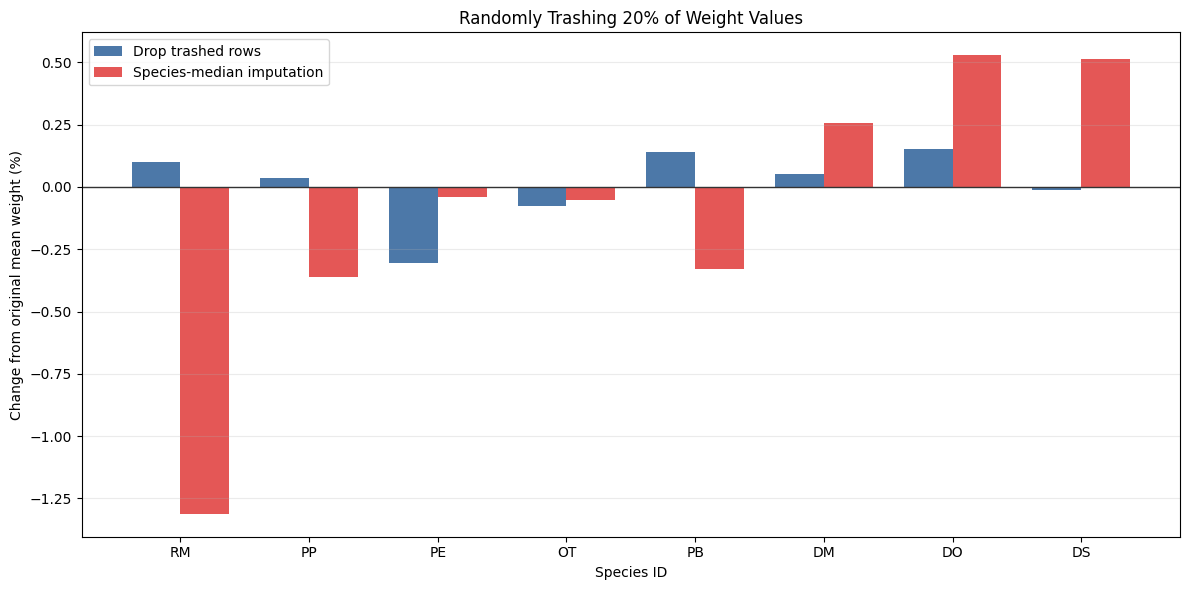

In [80]:
# FIG 9.2

x_positions = np.arange(len(random_comparison))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))
ax.axhline(0, color='#333333', linewidth=1)
ax.bar(x_positions - width / 2, random_comparison['drop_percent_change'], width=width, label='Drop trashed rows', color='#4C78A8')
ax.bar(x_positions + width / 2, random_comparison['impute_percent_change'], width=width, label='Species-median imputation', color='#E45756')
ax.set_title('Randomly Trashing 20% of Weight Values')
ax.set_xlabel('Species ID')
ax.set_ylabel('Change from original mean weight (%)')
ax.set_xticks(x_positions)
ax.set_xticklabels(random_comparison['species_id'])
ax.grid(axis='y', alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


Following the simulation, we can see that imputing the data actually causes more of a change in the results than dropping the missing data entirely does. In this specific situation, it's easier to get rid of the rows that are missing data and continue with clean rows. This result is likely specific to this scenario, and it's important to check what is the best method for each dataset being worked with. 

Further, if the analysis is only being conducted on a specific species, or group, the result of this analysis should be taken from that specific group. There ARE cases where imputing is better than dropping values, but the acerage result from each group is that dropping the data is better. 


## Study 3: Random missingness plus one species hit harder

**Scenario/question:** What happens if the whole dataset loses 20% of its weight values, and then one species loses an additional 20% of its remaining weight values?


In [81]:
rng = np.random.default_rng(RANDOM_SEED)
species_counts = complete_weight_df['species_id'].value_counts()
eligible_species = species_counts[species_counts >= 500].index.to_numpy()
target_species = rng.choice(eligible_species)
comparison_species = species_counts.drop(index=target_species).index[0]

species_missing_df = complete_weight_df.copy()
global_trash_index = rng.choice(species_missing_df.index, size=int(len(species_missing_df) * 0.20), replace=False)
species_missing_df.loc[global_trash_index, 'weight'] = np.nan
species_missing_df['missing_scenario'] = 'observed'
species_missing_df.loc[global_trash_index, 'missing_scenario'] = 'global 20% trash'

remaining_target_index = species_missing_df.loc[
    species_missing_df['species_id'].eq(target_species) & species_missing_df['weight'].notna()
].index
target_trash_index = rng.choice(remaining_target_index, size=int(len(remaining_target_index) * 0.20), replace=False)
species_missing_df.loc[target_trash_index, 'weight'] = np.nan
species_missing_df.loc[target_trash_index, 'missing_scenario'] = 'target species extra 20% trash'

focus_species = [target_species, comparison_species]
original_summary = (
    complete_weight_df[complete_weight_df['species_id'].isin(focus_species)]
    .groupby('species_id')
    .agg(original_rows=('weight', 'size'), original_mean_weight=('weight', 'mean'))
)
drop_summary = (
    species_missing_df[species_missing_df['species_id'].isin(focus_species)]
    .dropna(subset=['weight'])
    .groupby('species_id')
    .agg(rows_after_dropping=('weight', 'size'), mean_after_dropping=('weight', 'mean'))
)
species_scenario = original_summary.join(drop_summary).reset_index()
species_scenario['rows_lost'] = species_scenario['original_rows'] - species_scenario['rows_after_dropping']
species_scenario['mean_weight_change'] = species_scenario['mean_after_dropping'] - species_scenario['original_mean_weight']
species_scenario['scenario_label'] = np.where(
    species_scenario['species_id'].eq(target_species),
    f'{target_species} (global + species removal)',
    f'{comparison_species} (global removal only)'
)

print(f'Target species selected with seed {RANDOM_SEED}: {target_species}')
species_scenario


Target species selected with seed 42: PP


,species_id,original_rows,original_mean_weight,rows_after_dropping,mean_after_dropping,rows_lost,mean_weight_change,scenario_label
0,DM,18086,43.526153,14465,43.548496,3621,0.022344,DM (global removal only)
1,PP,18639,17.345941,12029,17.350071,6610,0.004129,PP (global + species removal)


The analysis above simulates uneven missingness. The target species is selected reproducibly using a random seed from species with enough records. The comparison species receives only the global random missingness.

The important result is not only whether the mean changes. The sample size also changes unevenly. A species with many missing values may look less stable, less comparable, or less important simply because fewer rows survive the cleaning rule.


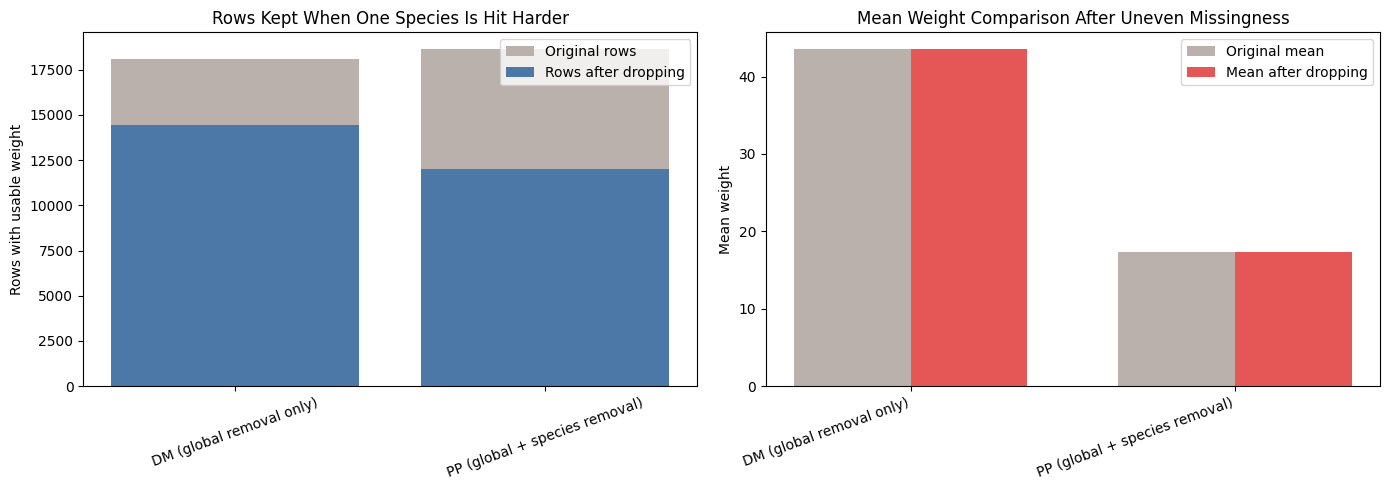

In [82]:
# FIG 9.3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(species_scenario['scenario_label'], species_scenario['original_rows'], label='Original rows', color='#BAB0AC')
axes[0].bar(species_scenario['scenario_label'], species_scenario['rows_after_dropping'], label='Rows after dropping', color='#4C78A8')
axes[0].set_title('Rows Kept When One Species Is Hit Harder')
axes[0].set_ylabel('Rows with usable weight')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend()

x_positions = np.arange(len(species_scenario))
width = 0.36
axes[1].bar(x_positions - width / 2, species_scenario['original_mean_weight'], width=width, label='Original mean', color='#BAB0AC')
axes[1].bar(x_positions + width / 2, species_scenario['mean_after_dropping'], width=width, label='Mean after dropping', color='#E45756')
axes[1].set_title('Mean Weight Comparison After Uneven Missingness')
axes[1].set_ylabel('Mean weight')
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(species_scenario['scenario_label'], rotation=20, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()


In this case, the PP species had less of an average change than the DM species had, even though the PP species had a larger percent of data missing. This data may have a species that are very close to their averages, meaning the amount of missing data has little effect on the average statistics being reported.  


## Study 4: Flood simulation in one plot

**Scenario/question:** What if there is a flood in plot 21 during 2007, and usable weight measurements from that plot-year are lost?


In [83]:
flood_plot_id = 21
flood_year = 2007
flood_missing_fraction = 0.90

rng = np.random.default_rng(RANDOM_SEED)
flood_df = complete_weight_df.copy()
flood_mask = flood_df['plot_id'].eq(flood_plot_id) & flood_df['year'].eq(flood_year)
flood_candidate_index = flood_df.loc[flood_mask].index
n_to_remove = int(round(len(flood_candidate_index) * flood_missing_fraction))

flood_trash_index = rng.choice(
    flood_candidate_index,
    size=n_to_remove,
    replace=False
)

flood_df['weight_after_flood_scenario'] = flood_df['weight']
flood_df.loc[flood_trash_index, 'weight_after_flood_scenario'] = np.nan

plot_year_original = (
    complete_weight_df[complete_weight_df['plot_id'].eq(flood_plot_id)]
    .groupby('year')
    .agg(original_usable_rows=('weight', 'size'), original_mean_weight=('weight', 'mean'))
    .reset_index()
)
plot_year_flood = (
    flood_df[flood_df['plot_id'].eq(flood_plot_id)]
    .groupby('year')
    .agg(
        usable_rows_after_flood=('weight_after_flood_scenario', lambda values: values.notna().sum()),
        mean_weight_after_flood=('weight_after_flood_scenario', 'mean')
    )
    .reset_index()
)
flood_summary = plot_year_original.merge(plot_year_flood, on='year', how='outer').sort_values('year')

actual_removed_percent = len(flood_trash_index) / len(flood_candidate_index) * 100
print(
    f'Simulated flood removed {len(flood_trash_index):,} of {len(flood_candidate_index):,} '
    f'usable weight records from plot {flood_plot_id} in {flood_year} '
    f'({actual_removed_percent:.1f}%).'
)
flood_summary.loc[flood_summary['year'].between(flood_year - 2, flood_year + 2)]


Simulated flood removed 185 of 206 usable weight records from plot 21 in 2007 (89.8%).


,year,original_usable_rows,original_mean_weight,usable_rows_after_flood,mean_weight_after_flood
28,2005,92,26.043478,92,26.043478
29,2006,89,28.808989,89,28.808989
30,2007,206,34.582524,21,28.380952
31,2008,113,29.707965,113,29.707965
32,2009,53,28.528302,53,28.528302


The analysis above randomly removes 90% of the weight values from one specific plot-year. Unlike random missingness, the missingness is tied to both location and time. That is closer to a field problem: a flood, equipment failure, access issue, or damaged plot could remove data from one part of the study design.

A plot-year event creates a visible drop in usable data. If the analysis drops missing rows, the affected year may still have a mean weight estimate, but that estimate is based on only the small fraction of records that survived the event.


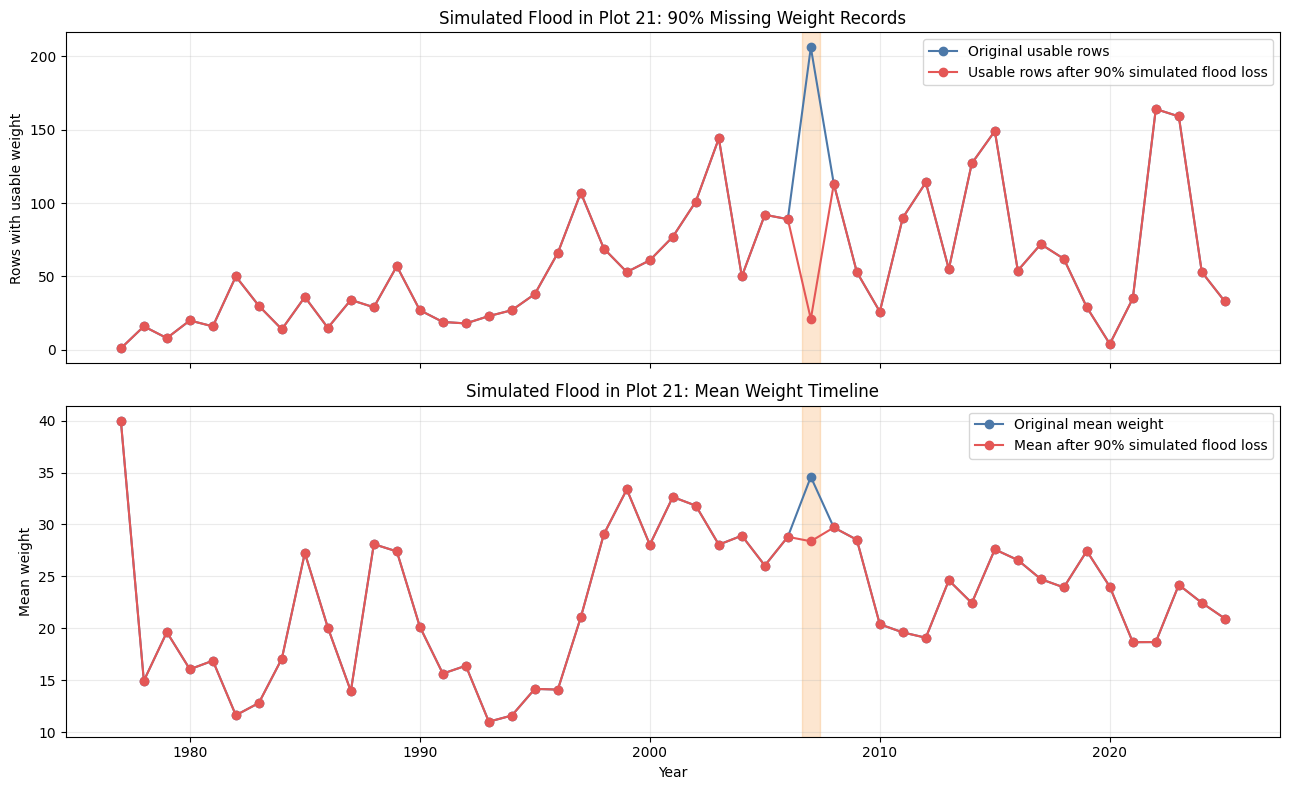

In [84]:
# FIG 9.4

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(flood_summary['year'], flood_summary['original_usable_rows'], marker='o', label='Original usable rows', color='#4C78A8')
axes[0].plot(flood_summary['year'], flood_summary['usable_rows_after_flood'], marker='o', label='Usable rows after 90% simulated flood loss', color='#E45756')
axes[0].axvspan(flood_year - 0.4, flood_year + 0.4, color='#F58518', alpha=0.2)
axes[0].set_title(f'Simulated Flood in Plot {flood_plot_id}: 90% Missing Weight Records')
axes[0].set_ylabel('Rows with usable weight')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(flood_summary['year'], flood_summary['original_mean_weight'], marker='o', label='Original mean weight', color='#4C78A8')
axes[1].plot(flood_summary['year'], flood_summary['mean_weight_after_flood'], marker='o', label='Mean after 90% simulated flood loss', color='#E45756')
axes[1].axvspan(flood_year - 0.4, flood_year + 0.4, color='#F58518', alpha=0.2)
axes[1].set_title(f'Simulated Flood in Plot {flood_plot_id}: Mean Weight Timeline')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Mean weight')
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()


From the visual, we can see how an event within collecting data can have such a large difference in the data. The chances of a flood happening to a particular group is random in chance, but the effect shows a new story. The original data showed a peak in mean weight, but the new data shows a more flat stroy, even displaying a bit of a dip in mean weight. That completely changes the insights for the year 2007, and hides important data. 

If someone were to be analyzing data in the future and notices 90% of the data missing, it may be a hidden narrative or event that happened, and further researching the data and understanding the story is an important step when deciding how to analyze the data. 

## Final Conclusion

Missing data analysis should start by asking where the missingness is located, not only how much data is missing.

Randomly removing 20% of the data is useful because it shows the best-case version of missingness: the missing rows are spread across the dataset without favoring a species, plot, or year. In that case, dropping rows or imputing with a simple species median may produce results that stay close to the original dataset.

The other scenarios are more dangerous. If one species loses extra data, then a species comparison becomes partly a comparison of data quality. If one plot-year is damaged by a flood or another field event, then the timeline can show a gap that reflects sampling conditions rather than animal biology.

A strong missing-data workflow should therefore report:

- Which variables are missing.
- Which species, plots, and years are most affected.
- Whether missingness was simulated randomly or tied to a group/event.
- How the conclusion changes under dropping versus imputation.

The final analytical choice is not just technical. It is an assumption about what the missing values mean.
